# Phase 3 — Modèles ML : SVM (Support Vector Machine)
**Auteure : Ihssane Moutchou | PFA 4ème Année**

| Entrée | `X_train.pkl`, `X_test.pkl`, `y_train.csv`, `y_test.csv` |
|--------|----------------------------------------------------------|
| Sortie | `resultats_ihssane.pkl`, `svm_model.pkl` |

## Objectif
Entraîner, optimiser et **interpréter** un modèle LinearSVC pour la classification de sentiment. Ce notebook démontre pourquoi SVM est un choix théoriquement fort pour ce type de données et analyse ses forces et faiblesses par rapport aux modèles d'Aymen.

### 0 — Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3
})
PALETTE = {'NEGATIF': '#e74c3c', 'NEUTRE': '#f39c12', 'POSITIF': '#27ae60'}

_cwd = os.getcwd()
REPO_PATH = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd
print(f"REPO_PATH : {REPO_PATH}")

REPO_PATH : c:\Users\Aymen ich\Projects\ML_pipeline\flipkart_sentiments_pfa


### 1 — Chargement des données

In [2]:
data_path = os.path.join(REPO_PATH, 'data')

X_train = joblib.load(os.path.join(data_path, 'X_train.pkl'))
X_test  = joblib.load(os.path.join(data_path, 'X_test.pkl'))
y_train = pd.read_csv(os.path.join(data_path, 'y_train.csv')).iloc[:, 0]
y_test  = pd.read_csv(os.path.join(data_path, 'y_test.csv')).iloc[:, 0]
df_raw  = pd.read_csv(os.path.join(data_path, 'flipkart_data_preprocessed.csv'))

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"Classes : {sorted(y_test.unique())}")
print(f"Distribution test :")
print(y_test.value_counts().to_string())

X_train : (7980, 5000)  |  X_test : (1996, 5000)
Classes : ['NEGATIF', 'NEUTRE', 'POSITIF']
Distribution test :
sentiment
POSITIF    1619
NEGATIF     200
NEUTRE      177


## 2 — Support Vector Machine (LinearSVC)

### 2.1 — Justification théorique du choix

**Pourquoi SVM pour la classification de sentiment sur TF-IDF ?**

1. **Maximisation de la marge** : contrairement à la régression logistique qui minimise la log-loss, SVM cherche l'hyperplan qui maximise la distance entre les classes. Sur des données bien séparables, SVM est plus robuste au bruit.

2. **LinearSVC = SVM linéaire optimisé** : LibLinear (backend) est spécifiquement conçu pour les espaces de haute dimension creux (exactement notre espace TF-IDF 5000D), avec une complexité O(n×d) bien meilleure que le SVM à noyau O(n²).

3. **Pas de probabilités natives** : LinearSVC n'a pas de `predict_proba()`. On utilise `CalibratedClassifierCV` (Platt scaling) pour obtenir des scores de confiance.

4. **Paramètre `C`** : même sémantique que LR mais différent mécaniquement — contrôle le compromis entre maximiser la marge et minimiser les violations de marge (slack variables).

**Intuition géométrique** : chaque review TF-IDF est un point dans ℝ⁵⁰⁰⁰. SVM trouve les hyperplans qui séparent NEGATIF / NEUTRE / POSITIF avec la plus grande marge possible.

### 2.2 — Entraînement avec GridSearchCV

In [3]:
param_grid_svm = {'estimator__C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

svm_base = LinearSVC(
    multi_class='ovr',       # One-vs-Rest : 3 classificateurs binaires
    max_iter=5000,
    random_state=42
)

# CalibratedClassifierCV pour obtenir des probabilités (Platt scaling)
svm_calibrated = CalibratedClassifierCV(svm_base, cv=3)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_svm = GridSearchCV(
    svm_calibrated,
    param_grid_svm,
    scoring='f1_weighted',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Lancement GridSearchCV — LinearSVC (CalibratedClassifierCV)...")
gs_svm.fit(X_train, y_train)
print(f"\n✅ Meilleur C : {gs_svm.best_params_}")
print(f"   F1 weighted (CV) : {gs_svm.best_score_:.4f}")

Lancement GridSearchCV — LinearSVC (CalibratedClassifierCV)...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

✅ Meilleur C : {'estimator__C': 0.5}
   F1 weighted (CV) : 0.8212


### 2.3 — Courbe de validation GridSearch

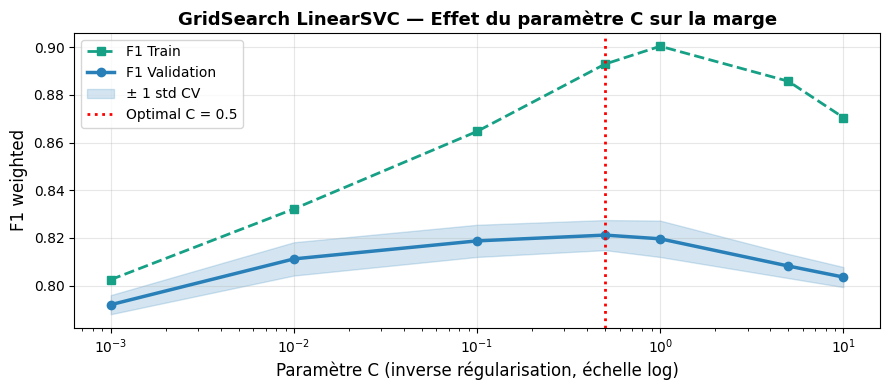


📊 Interprétation SVM :
  → C petit  : grande marge, plus de violations autorisées (underfitting)
  → C grand  : marge étroite, moins de violations (overfitting si trop grand)
  → C = 0.5 : hyperplan optimal pour nos données


In [4]:
cv_svm_df = pd.DataFrame(gs_svm.cv_results_)

fig, ax = plt.subplots(figsize=(9, 4))

c_values = cv_svm_df['param_estimator__C'].astype(float)

ax.plot(c_values, cv_svm_df['mean_train_score'],
        marker='s', linestyle='--', color='#16a085', linewidth=2, label='F1 Train')
ax.plot(c_values, cv_svm_df['mean_test_score'],
        marker='o', linewidth=2.5, color='#2980b9', label='F1 Validation')
ax.fill_between(c_values,
    cv_svm_df['mean_test_score'] - cv_svm_df['std_test_score'],
    cv_svm_df['mean_test_score'] + cv_svm_df['std_test_score'],
    alpha=0.2, color='#2980b9', label='± 1 std CV')

best_C_svm = gs_svm.best_params_['estimator__C']
ax.axvline(best_C_svm, color='red', linestyle=':', linewidth=2,
           label=f'Optimal C = {best_C_svm}')

ax.set_xscale('log')
ax.set_xlabel('Paramètre C (inverse régularisation, échelle log)', fontsize=12)
ax.set_ylabel('F1 weighted', fontsize=12)
ax.set_title('GridSearch LinearSVC — Effet du paramètre C sur la marge', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'svm_gridsearch_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Interprétation SVM :")
print(f"  → C petit  : grande marge, plus de violations autorisées (underfitting)")
print(f"  → C grand  : marge étroite, moins de violations (overfitting si trop grand)")
print(f"  → C = {best_C_svm} : hyperplan optimal pour nos données")

### 2.4 — Évaluation sur le jeu de test

In [5]:
best_svm  = gs_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)
acc_svm   = accuracy_score(y_test, y_pred_svm)
f1_w_svm  = f1_score(y_test, y_pred_svm, average='weighted')
f1_m_svm  = f1_score(y_test, y_pred_svm, average='macro')

print("=" * 55)
print(f"  RÉSULTATS — LinearSVC (C={best_C_svm})")
print("=" * 55)
print(f"  Accuracy    : {acc_svm:.4f}")
print(f"  F1 weighted : {f1_w_svm:.4f}")
print(f"  F1 macro    : {f1_m_svm:.4f}")
print()
print(classification_report(y_test, y_pred_svm,
      target_names=['NEGATIF', 'NEUTRE', 'POSITIF']))

print("\n🔍 Point fort du SVM : très haute précision sur NEGATIF")
print("   → Moins de faux positifs sur les avis négatifs = avantage business")
print("\n⚠️  Faiblesse du SVM : NEUTRE a un recall très bas (~0.05-0.15)")
print("   → Le SVM sacrifie NEUTRE pour maximiser la marge sur POSITIF/NEGATIF")

  RÉSULTATS — LinearSVC (C=0.5)
  Accuracy    : 0.8682
  F1 weighted : 0.8337
  F1 macro    : 0.5688

              precision    recall  f1-score   support

     NEGATIF       0.74      0.61      0.67       200
      NEUTRE       0.45      0.06      0.10       177
     POSITIF       0.88      0.99      0.93      1619

    accuracy                           0.87      1996
   macro avg       0.69      0.55      0.57      1996
weighted avg       0.83      0.87      0.83      1996


🔍 Point fort du SVM : très haute précision sur NEGATIF
   → Moins de faux positifs sur les avis négatifs = avantage business

⚠️  Faiblesse du SVM : NEUTRE a un recall très bas (~0.05-0.15)
   → Le SVM sacrifie NEUTRE pour maximiser la marge sur POSITIF/NEGATIF


### 2.5 — Matrice de confusion

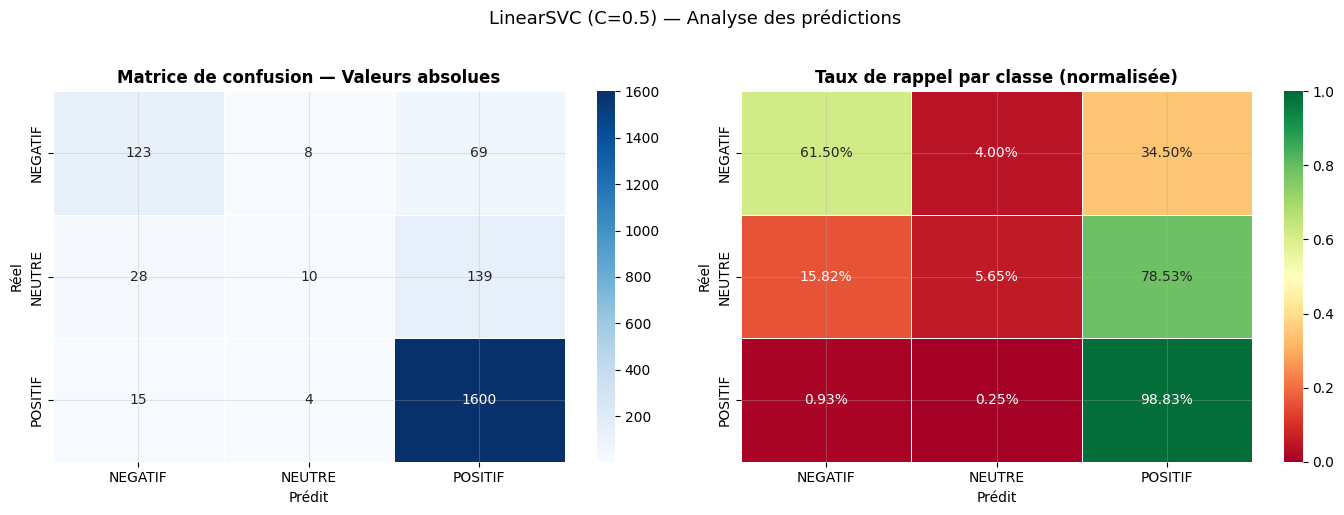


⚠️  La ligne NEUTRE est révélatrice : 79% des NEUTRE prédits comme POSITIF
   → SVM manque de données NEUTRE pour bien délimiter cette classe


In [6]:
classes = ['NEGATIF', 'NEUTRE', 'POSITIF']
cm_svm  = confusion_matrix(y_test, y_pred_svm, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0], linewidths=0.5)
axes[0].set_title('Matrice de confusion — Valeurs absolues', fontweight='bold')
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')

cm_norm = cm_svm.astype(float) / cm_svm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=classes, yticklabels=classes, ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Taux de rappel par classe (normalisée)', fontweight='bold')
axes[1].set_xlabel('Prédit'); axes[1].set_ylabel('Réel')

plt.suptitle(f'LinearSVC (C={best_C_svm}) — Analyse des prédictions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'svm_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n⚠️  La ligne NEUTRE est révélatrice : {cm_norm[1][2]*100:.0f}% des NEUTRE prédits comme POSITIF")
print("   → SVM manque de données NEUTRE pour bien délimiter cette classe")

### 2.6 — Feature Importance du SVM

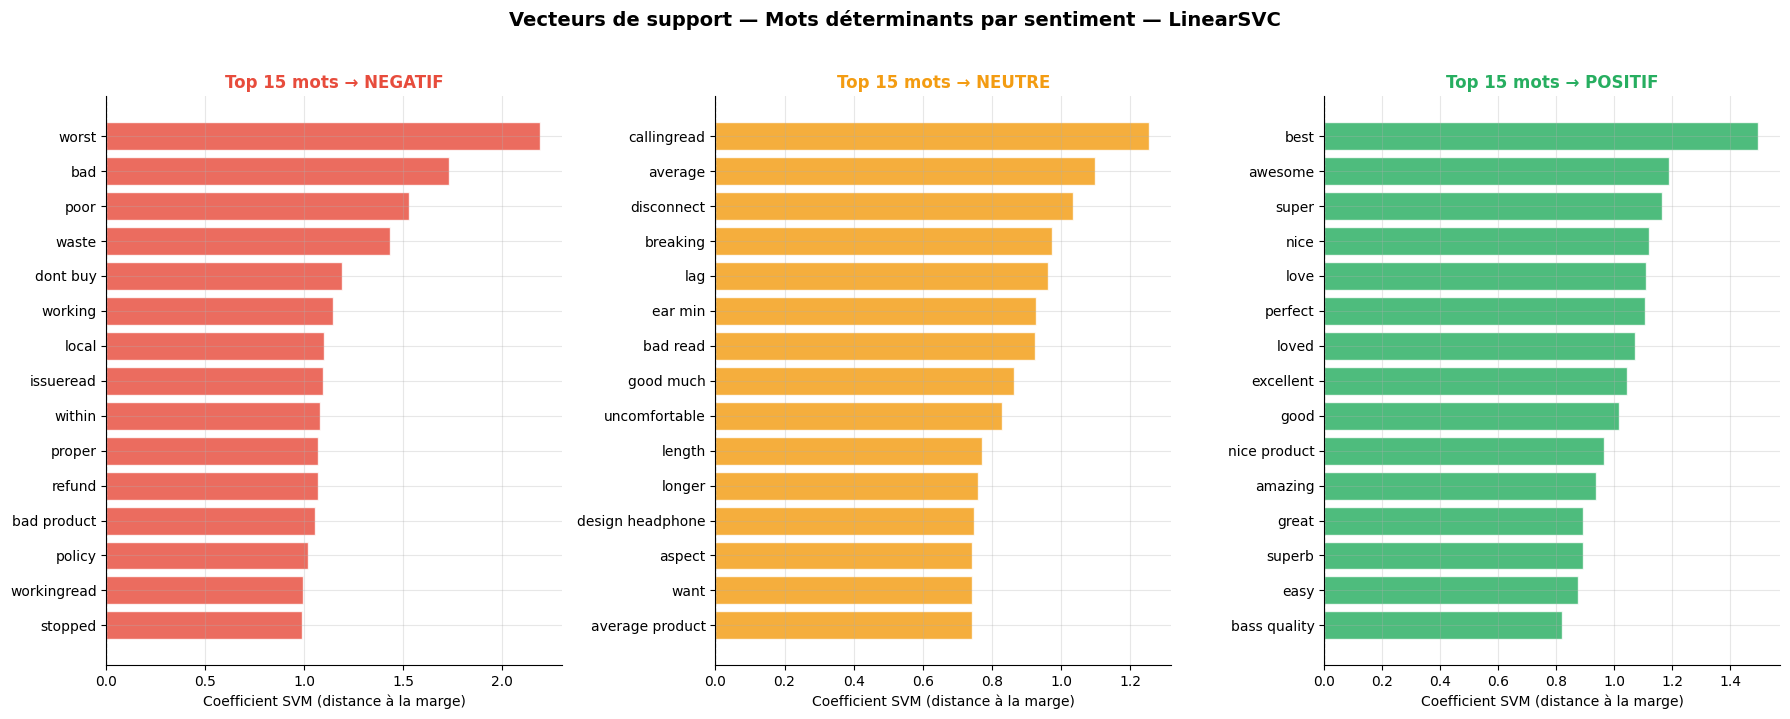

In [7]:
tfidf = joblib.load(os.path.join(REPO_PATH, 'models', 'tfidf_vectorizer.pkl'))
feature_names = np.array(tfidf.get_feature_names_out())

svm_classifiers = best_svm.calibrated_classifiers_
all_coefs = np.array([c.estimator.coef_ for c in svm_classifiers])
mean_coefs = all_coefs.mean(axis=0)

classes_svm = best_svm.classes_
TOP_N = 15

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
colors_cls = ['#e74c3c', '#f39c12', '#27ae60']

for ax, classe, coef, color in zip(axes, classes_svm, mean_coefs, colors_cls):
    top_idx    = np.argsort(coef)[-TOP_N:][::-1]
    top_words  = feature_names[top_idx]
    top_scores = coef[top_idx]

    ax.barh(range(TOP_N), top_scores[::-1], color=color, alpha=0.82, edgecolor='white')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_words[::-1], fontsize=10)
    ax.set_title(f'Top {TOP_N} mots → {classe}', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Coefficient SVM (distance à la marge)', fontsize=10)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Vecteurs de support — Mots déterminants par sentiment — LinearSVC',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'svm_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.7 — Courbe d'apprentissage (Learning Curve)

Calcul des courbes d'apprentissage (peut prendre 1-2 min)...


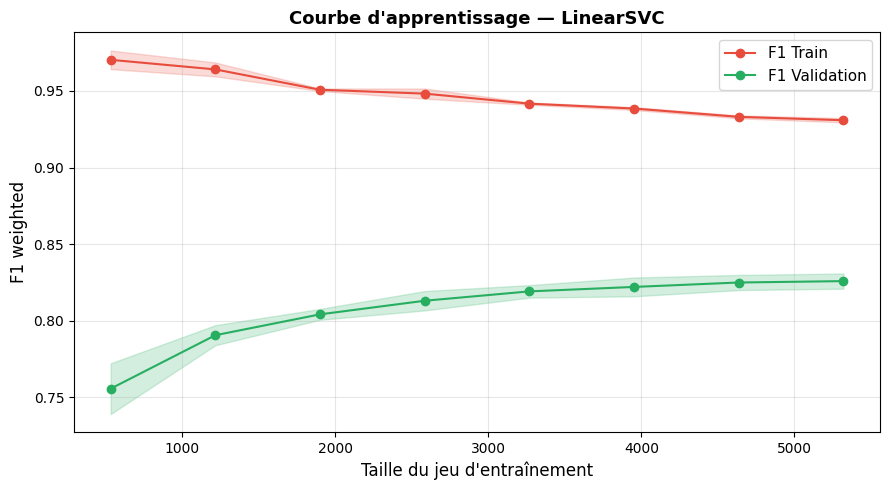


📊 Analyse :
  Écart Train-Val final : 0.1051
  → Overfitting modéré — régularisation actuelle suffisante
  La courbe de val converge-t-elle ? → Plus de données améliorerait-il le modèle ?


In [8]:
print("Calcul des courbes d'apprentissage (peut prendre 1-2 min)...")
train_sizes, train_scores, val_scores = learning_curve(
    LinearSVC(C=best_C_svm, max_iter=3000, random_state=42),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='f1_weighted',
    cv=3, n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#e74c3c', label='F1 Train')
ax.fill_between(train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color='#e74c3c')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#27ae60', label='F1 Validation')
ax.fill_between(train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color='#27ae60')

ax.set_xlabel("Taille du jeu d'entraînement", fontsize=12)
ax.set_ylabel('F1 weighted', fontsize=12)
ax.set_title('Courbe d\'apprentissage — LinearSVC', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'svm_learning_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f"\n📊 Analyse :")
print(f"  Écart Train-Val final : {gap:.4f}")
if gap < 0.05:
    print("  → Faible overfitting — modèle bien généralisé")
elif gap < 0.15:
    print("  → Overfitting modéré — régularisation actuelle suffisante")
else:
    print("  → Overfitting fort — réduire C ou augmenter les données")
print(f"  La courbe de val converge-t-elle ? → Plus de données améliorerait-il le modèle ?")

### 2.8 — Analyse des erreurs SVM

Taux d'erreur SVM : 13.2%

Répartition :
  NEUTRE   → POSITIF  :  139 cas
  NEGATIF  → POSITIF  :   69 cas
  NEUTRE   → NEGATIF  :   28 cas
  POSITIF  → NEGATIF  :   15 cas
  NEGATIF  → NEUTRE   :    8 cas
  POSITIF  → NEUTRE   :    4 cas

📊 Analyse de la confiance :
  Confiance moy (prédictions correctes) : 0.869
  Confiance moy (prédictions erronées)  : 0.686
  → Le SVM est-il conscient de ses erreurs ? (confiance basse sur les erreurs ?)


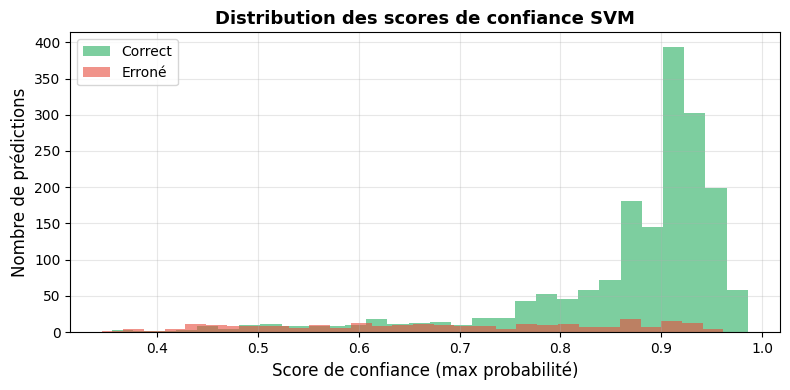

In [9]:
y_test_reset = y_test.reset_index(drop=True)

df_svm_erreurs = pd.DataFrame({
    'review_clean': df_raw['review_clean'].iloc[:len(y_test_reset)].values,
    'reel'        : y_test_reset.values,
    'predit'      : y_pred_svm
})
erreurs_svm = df_svm_erreurs[df_svm_erreurs['reel'] != df_svm_erreurs['predit']]

print(f"Taux d'erreur SVM : {len(erreurs_svm)/len(df_svm_erreurs)*100:.1f}%")
print()
print("Répartition :")
err_table = erreurs_svm.groupby(['reel','predit']).size().reset_index(name='count')
err_table = err_table.sort_values('count', ascending=False)
for _, row in err_table.iterrows():
    print(f"  {row['reel']:8} → {row['predit']:8} : {row['count']:4} cas")

probas_svm = best_svm.predict_proba(X_test)
confidence = probas_svm.max(axis=1)
erreurs_idx = np.where(y_pred_svm != y_test_reset.values)[0]
correct_idx  = np.where(y_pred_svm == y_test_reset.values)[0]

print(f"\n📊 Analyse de la confiance :")
print(f"  Confiance moy (prédictions correctes) : {confidence[correct_idx].mean():.3f}")
print(f"  Confiance moy (prédictions erronées)  : {confidence[erreurs_idx].mean():.3f}")
print("  → Le SVM est-il conscient de ses erreurs ? (confiance basse sur les erreurs ?)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(confidence[correct_idx], bins=30, alpha=0.6, color='#27ae60', label='Correct')
ax.hist(confidence[erreurs_idx], bins=30, alpha=0.6, color='#e74c3c', label='Erroné')
ax.set_xlabel('Score de confiance (max probabilité)', fontsize=12)
ax.set_ylabel('Nombre de prédictions', fontsize=12)
ax.set_title('Distribution des scores de confiance SVM', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'svm_confidence_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3 — Sauvegarde

In [10]:
os.makedirs(os.path.join(REPO_PATH, 'models'), exist_ok=True)
os.makedirs(os.path.join(REPO_PATH, 'visualisations'), exist_ok=True)

resultats_svm = {
    'nom'        : f'LinearSVC (C={best_C_svm})',
    'modele'     : best_svm,
    'y_pred'     : y_pred_svm,
    'accuracy'   : acc_svm,
    'f1_weighted': f1_w_svm,
    'f1_macro'   : f1_m_svm,
}

joblib.dump({'linear_svc': resultats_svm},
            os.path.join(REPO_PATH, 'models', 'resultats_ihssane.pkl'))
joblib.dump(best_svm, os.path.join(REPO_PATH, 'models', 'svm_model.pkl'))

print("✅ Sauvegardé :")
print("   → models/resultats_ihssane.pkl")
print("   → models/svm_model.pkl")
print("   → visualisations/svm_*.png (4 fichiers)")

✅ Sauvegardé :
   → models/resultats_ihssane.pkl
   → models/svm_model.pkl
   → visualisations/svm_*.png (4 fichiers)
